# Spotify + Lyrics Analysis

**Trabajo individual — Análisis de datos de Spotify con letras de canciones**

---

## Objetivos

1. **Punto 1 (2 pts):** Filtrar los álbumes de cada artista para que sólo aparezcan los de **estudio** (según Wikipedia).
2. **Punto 2 (4 pts):** Incorporar componentes/gráficos para explorar las **letras** de canciones usando [lyrics.ovh](https://lyrics.ovh/).
3. **Punto 3 (4 pts):** Web app con Streamlit (ver `app.py` adjunto).

---

**Dataset:** [Spotify 1.2M+ Songs — Kaggle](https://www.kaggle.com/datasets/rodolfofigueroa/spotify-12m-songs)  
**API de letras:** [lyrics.ovh](https://api.lyrics.ovh/v1/{artist}/{title})  
**Referencia audio features:** [Spotify API docs](https://developer.spotify.com/documentation/web-api/reference/get-audio-features)

## 0. Instalación y configuración

In [1]:
# Instalar dependencias necesarias
!pip install gdown requests wordcloud -q


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import ast
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='tab10')

Realizamos los imports necesarios.

In [3]:
# Descargar el dataset de Kaggle si no existe
DATA_FILE = 'tracks_features.csv'

if not os.path.exists(DATA_FILE):
    print('Descargando dataset...')
    !gdown 1jsXTNtGhOrsCApQctYx-hRxAQASAcPlI
else:
    print(f'{DATA_FILE} ya existe, saltando descarga.')

tracks_features.csv ya existe, saltando descarga.


In [4]:
# Cargar el dataset
df = pd.read_csv(DATA_FILE)
print(f'Shape del dataset: {df.shape}')

AUDIO_FEATURES = [
    'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'speechiness',
    'tempo', 'valence'
]

Shape del dataset: (1204025, 24)


---
## Filtrado de Álbumes de Estudio

Definimos manualmente los **álbumes de estudio** de cada Fleetwood Mac,
consultando su discografía en Wikipedia.
Excluimos:
- Recopilaciones (*Best of*, *Greatest Hits*)
- Álbumes en directo (*Live at...*)
- EPs y singles
- Reediciones con sufijos *(Remastered)*, *(Deluxe Edition)*

In [5]:
ARTISTS_CONFIG = {
    'Fleetwood Mac': {
        'spotify_id': '08GQAI4eElDnROBrJRGE0X',
        # Fuente: https://es.wikipedia.org/wiki/Fleetwood_Mac
        'studio_albums': {
            'Fleetwood Mac',
            'Mr. Wonderful',
            'Then Play On',
            'Kiln House',
            'Future Games',
            'Bare Trees',
            'Penguin',
            'Mystery to Me',
            'Heroes Are Hard to Find',
            'Rumours',
            'Tusk',
            'Mirage',
            'Tango in the Night',
            'Behind the Mask',
            'Time',
            'Say You Will',
        },
    },
}

print('Configuración definida para', len(ARTISTS_CONFIG), 'artistas')

Configuración definida para 1 artistas


In [6]:
def artist_id_in_list(artist_ids_str, target_id):
    try:
        return target_id in ast.literal_eval(str(artist_ids_str))
    except Exception:
        return False


# Definimos una función para filtrar los álbumes de estudio automáticamente.
def filter_studio_albums(df, artist_name):
    """
    Pasos:
    1. Filtrar por artist_id de Spotify
    2. Normalizar nombre de álbum (quitar sufijos entre paréntesis)
    3. Mantener solo álbumes en la lista de estudio
    4. Deduplicar: una fila por (álbum, nombre de pista)
    """
    cfg = ARTISTS_CONFIG[artist_name]

    # 1. Filtro por ID de artista
    mask = df['artist_ids'].apply(lambda x: artist_id_in_list(x, cfg['spotify_id']))
    adf = df[mask].copy()

    # 2. Normalizar nombre de álbum: quitar (Remastered), (Deluxe), etc.
    adf['short_album_name'] = adf['album'].str.split('(').str[0].str.strip()

    # 3. Solo álbumes de estudio
    adf = adf[adf['short_album_name'].isin(cfg['studio_albums'])]

    # 4. Deduplicar manteniendo el más antiguo por año
    adf = (
        adf.sort_values('year')
        .drop_duplicates(subset=['short_album_name', 'name'], keep='first')
        .reset_index(drop=True)
    )

    return adf

# Así obtenemos los albumes en orden cronológico.

def get_album_order(adf):
    return (
        adf.drop_duplicates('short_album_name')
        .sort_values('year')['short_album_name']
        .tolist()
    )

Comprobamos el filtrado a ver si ha sido realizado correctamente.

In [7]:
ARTIST_NAME = 'Fleetwood Mac'

artist_df = filter_studio_albums(df, ARTIST_NAME)
ALBUM_ORDER = get_album_order(artist_df)

print(f'Artista: {ARTIST_NAME}')
print(f'Pistas tras filtrado: {len(artist_df)}')
print(f'Álbumes de estudio ({len(ALBUM_ORDER)}): {ALBUM_ORDER}')

Artista: Fleetwood Mac
Pistas tras filtrado: 333
Álbumes de estudio (15): ['Then Play On', 'Kiln House', 'Future Games', 'Bare Trees', 'Penguin', 'Mystery to Me', 'Heroes Are Hard to Find', 'Fleetwood Mac', 'Rumours', 'Tusk', 'Mirage', 'Tango in the Night', 'Behind the Mask', 'Time', 'Say You Will']


In [8]:
# Resumen por álbum
summary = (
    artist_df.groupby('short_album_name')
    .agg(Pistas=('name', 'count'), Año=('year', 'min'))
    .loc[ALBUM_ORDER]
)
print(summary.to_string())

                         Pistas   Año
short_album_name                     
Then Play On                 21  1969
Kiln House                   10  1970
Future Games                  8  1971
Bare Trees                   10  1972
Penguin                       9  1973
Mystery to Me                12  1973
Heroes Are Hard to Find      11  1974
Fleetwood Mac                56  1975
Rumours                      50  1977
Tusk                         47  1979
Mirage                       43  1982
Tango in the Night           12  1987
Behind the Mask              13  1990
Time                         13  1995
Say You Will                 18  2003


Mostramos también el contenido de número de pistas por álbum. Podemos ver detalles como la tendencia hacia la mitad de su carrera a crear álbumes más largos.

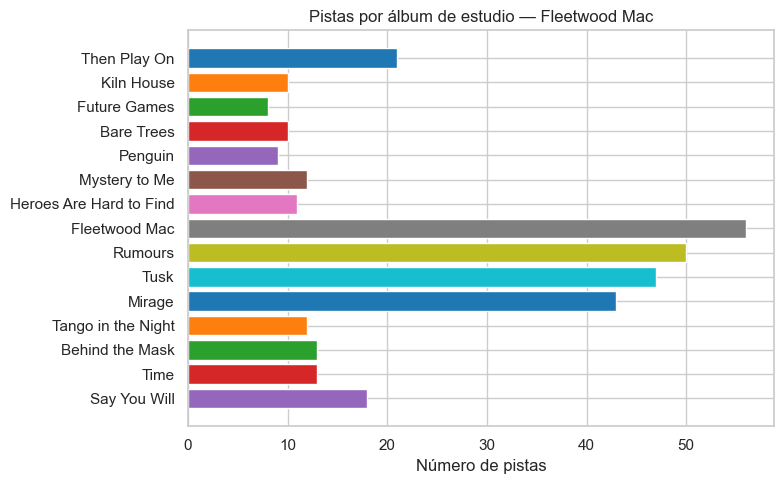

In [9]:
# Gráfico de pistas por álbum
tc = artist_df.groupby('short_album_name')['name'].count().loc[ALBUM_ORDER]
colors = sns.color_palette('tab10', len(ALBUM_ORDER))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(tc.index[::-1], tc.values[::-1], color=colors[::-1])
ax.set_xlabel('Número de pistas')
ax.set_title(f'Pistas por álbum de estudio — {ARTIST_NAME}')
plt.tight_layout()
plt.show()

## Acousticness vs. Valence

Graficamos la relación entre la positividad de una canción y su acusticidad. La relación que podemos observar es que no se detecta un gran número de canciones acústicas entre las pistas de sus álbumes de estudio.

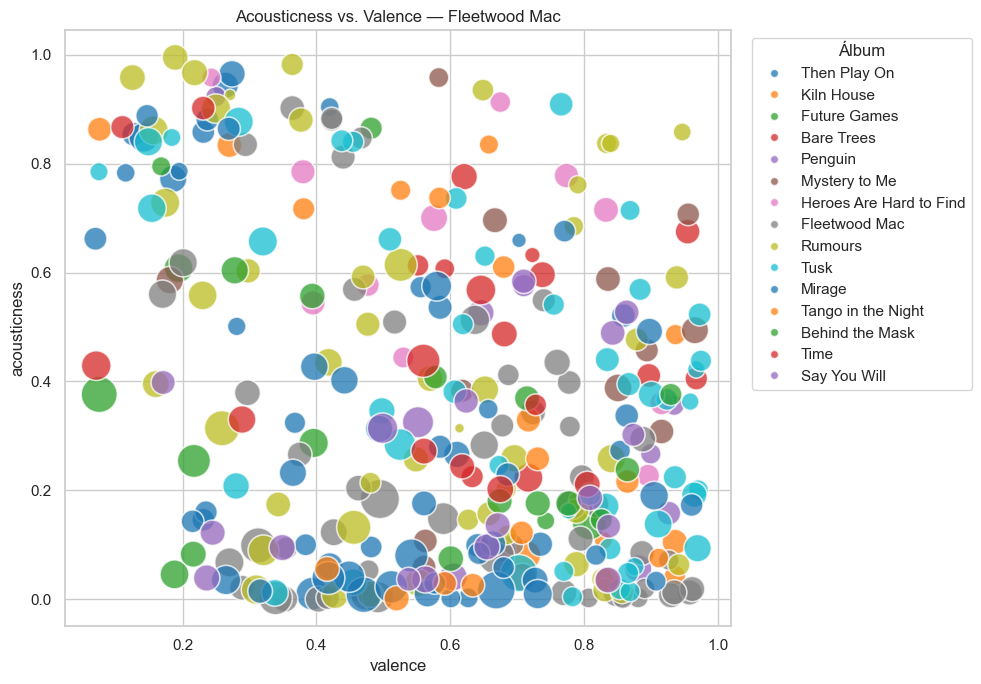

In [10]:
# Acousticness vs. Valence
fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', len(ALBUM_ORDER))

sns.scatterplot(
    data=artist_df, x='valence', y='acousticness',
    hue='short_album_name', hue_order=ALBUM_ORDER,
    palette='tab10', size='duration_ms', sizes=(50, 800),
    alpha=0.75, ax=ax
)

handles, labels = ax.get_legend_handles_labels()
n = len(ALBUM_ORDER)
ax.legend(handles[1:n+1], labels[1:n+1], title='Álbum', bbox_to_anchor=(1.02, 1))
ax.set_title(f'Acousticness vs. Valence — {ARTIST_NAME}')
plt.tight_layout()
plt.show()

También graficamos las características clasificadas de cada álbum. Ahí podemos ver, en relación a la gráfica anterior, cómo únicamente el álbum "Heroes are hard to find" es considerado acústico.

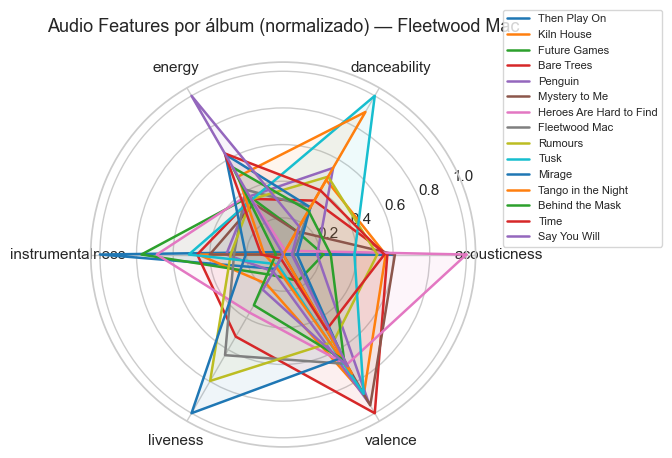

In [11]:
# Radar chart: features promedio por álbum
RADAR_FEATURES = ['acousticness', 'danceability', 'energy',
                  'instrumentalness', 'liveness', 'valence']

means = artist_df.groupby('short_album_name')[RADAR_FEATURES].mean().loc[ALBUM_ORDER]
norm  = (means - means.min()) / (means.max() - means.min() + 1e-9)

N      = len(RADAR_FEATURES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors  = sns.color_palette('tab10', len(ALBUM_ORDER))

for (album, row), color in zip(norm.iterrows(), colors):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, color=color, linewidth=1.8, label=album)
    ax.fill(angles, vals, color=color, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_FEATURES, size=11)
ax.set_title(f'Audio Features por álbum (normalizado) — {ARTIST_NAME}', size=13, pad=22)
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

---
## Análisis de Letras con lyrics.ovh

Usamos la API pública `https://api.lyrics.ovh/v1/{artista}/{canción}` para
obtener las letras en tiempo real. A partir de ellas analizamos:

1. **Nube de palabras** del vocabulario usado por álbum
2. **Frecuencia de palabras** más usadas
3. **Riqueza léxica** (vocabulario único / total de palabras, conocido como TTR)
4. **Comparativa entre álbumes**
5. **Consulta de letra individual**

Definimos las funciones necesarias para crear la nube de palabras. Además, definimos una lista de stop_words para limpiar la lista de palabras más usadas.

In [12]:
STOP_WORDS = {
    'i', 'me', 'my', 'you', 'your', 'the', 'a', 'an', 'and', 'or', 'but',
    'in', 'on', 'at', 'to', 'for', 'of', 'it', 'is', 'was', 'are', 'be',
    'have', 'had', 'do', 'did', 'will', 'would', 'can', 'could', 'that',
    'this', 'with', 'not', 'no', 'so', 'if', 'all', 'we', 'he', 'she',
    'they', 'them', 'their', 'its', 'what', 'when', 'where', 'how', 'why',
    'as', 'up', 'out', 'just', 'been', 'there', 'then', 'than', 'like',
    'from', 'into', 'about', 'get', 'got', 'oh', 'yeah', 'know', 'one',
    've', 're', 'll', 's', 't', 'm', 'dont', 'im', 'ive', 'aint', 'cause',
    'ain', 'em', 'gonna', 'wanna', 'gotta', 'let', 'come', 'go', 'say',
    'see', 'want', 'back', 'still', 'down', 'up', 'away', 'never', 'ever',
    'every', 'more', 'some', 'any', 'too', 'now', 'here', 'it\'s'
}


def fetch_lyrics(artist, title):
    try:
        url = f'https://api.lyrics.ovh/v1/{requests.utils.quote(artist)}/{requests.utils.quote(title)}'
        r = requests.get(url, timeout=8)
        if r.status_code == 200:
            return r.json().get('lyrics') or None
        return None
    except Exception:
        return None


def clean_lyrics(text):
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


def tokenize(text):
    return [w for w in re.findall(r"[a-z']+", text.lower())
            if w not in STOP_WORDS and len(w) > 3]


def lyrics_stats(lyrics):
    tokens = tokenize(lyrics)
    unique = set(tokens)
    return {
        'total_words': len(tokens),
        'unique_words': len(unique),
        'ttr': len(unique) / max(len(tokens), 1),
    }

Utilizamos uno de sus álbumes de estudio más nuevos para asegurar que los lyrics estén disponibles.

In [13]:
TARGET_ALBUM = 'Behind the Mask'
MAX_TRACKS   = 8

tracks_in_album = artist_df[artist_df['short_album_name'] == TARGET_ALBUM]['name'].tolist()
print(f'Pistas en "{TARGET_ALBUM}": {tracks_in_album[:MAX_TRACKS]}')
print('\nConsultando lyrics.ovh...')

album_lyrics = []
found_tracks = []

for track in tracks_in_album[:MAX_TRACKS]:
    lyr = fetch_lyrics(ARTIST_NAME, track)
    if lyr:
        album_lyrics.append(clean_lyrics(lyr))
        found_tracks.append(track)
        print(f'  {track}')
    else:
        print(f'  {track} — no encontrado')
    time.sleep(0.5)

print(f'\nLetras obtenidas: {len(album_lyrics)}/{len(tracks_in_album[:MAX_TRACKS])}')

Pistas en "Behind the Mask": ['The Second Time', 'When It Comes to Love', 'Freedom', 'Hard Feelings', 'Stand on the Rock', 'Behind the Mask', 'When the Sun Goes Down', 'Affairs of the Heart']

Consultando lyrics.ovh...
  The Second Time
  When It Comes to Love
  Freedom
  Hard Feelings
  Stand on the Rock
  Behind the Mask
  When the Sun Goes Down
  Affairs of the Heart

Letras obtenidas: 8/8


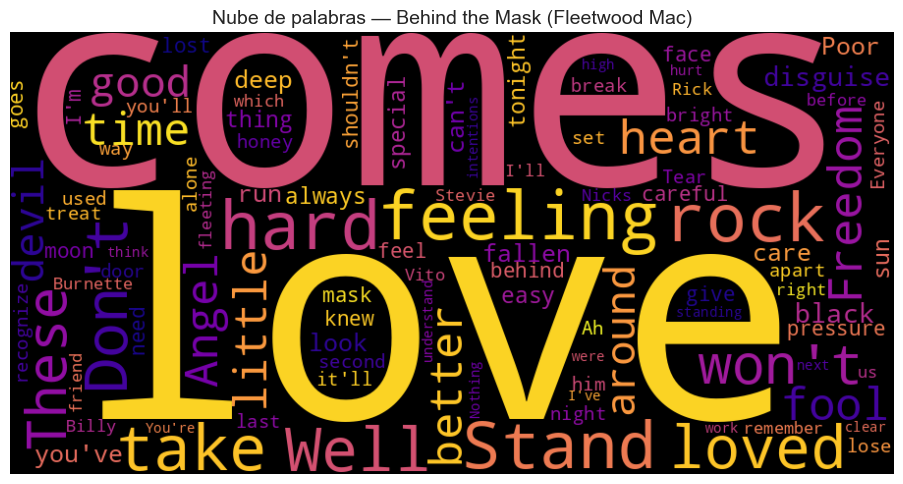

In [14]:
if album_lyrics:
    combined_text = ' '.join(album_lyrics)

    wc = WordCloud(
        width=900, height=450,
        background_color='black',
        colormap='plasma',
        stopwords=STOP_WORDS,
        max_words=100,
        collocations=False,
    ).generate(combined_text)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Nube de palabras — {TARGET_ALBUM} ({ARTIST_NAME})', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No hay letras disponibles para generar la nube.')

Creamos una gráfica de barras para poder ver la relación de palabras más usadas de una manera mas intuitiva.

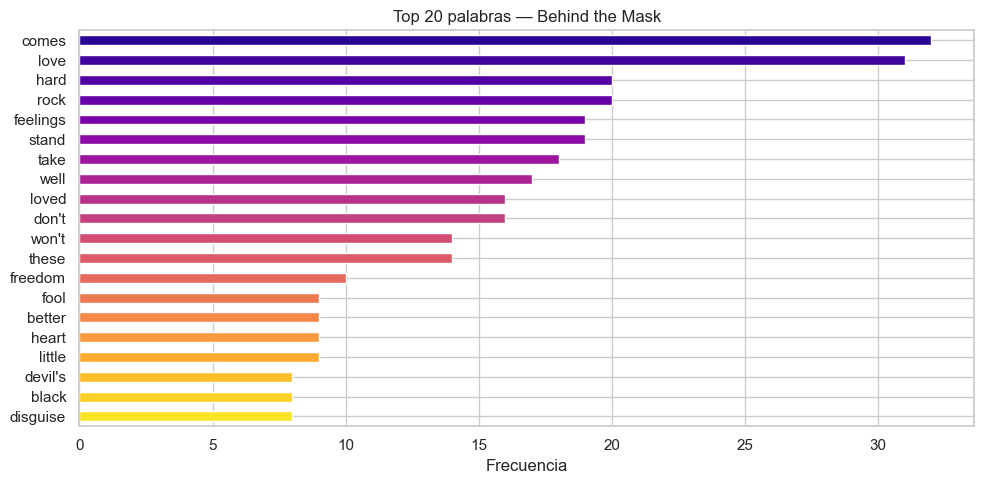


 Estadísticas de "Behind the Mask":
   Total de palabras (filtradas): 869
   Vocabulario único:             288
   Type-Token Ratio (TTR):        0.331


In [15]:
if album_lyrics:
    tokens = tokenize(combined_text)
    freq = pd.Series(Counter(tokens)).sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = sns.color_palette('plasma', len(freq))
    freq[::-1].plot(kind='barh', ax=ax, color=colors[::-1])
    ax.set_title(f'Top 20 palabras — {TARGET_ALBUM}')
    ax.set_xlabel('Frecuencia')
    plt.tight_layout()
    plt.show()

    # Estadísticas
    stats = lyrics_stats(combined_text)
    print(f'\n Estadísticas de "{TARGET_ALBUM}":')
    print(f'   Total de palabras (filtradas): {stats["total_words"]}')
    print(f'   Vocabulario único:             {stats["unique_words"]}')
    print(f'   Type-Token Ratio (TTR):        {stats["ttr"]:.3f}')

Añadimos también la visualización de la letra de una de sus canciones más famosas, "Silver Springs".

In [16]:
SONG_TITLE = 'Silver Springs'

lyr = fetch_lyrics(ARTIST_NAME, SONG_TITLE)

if lyr:
    cleaned = clean_lyrics(lyr)
    stats = lyrics_stats(cleaned)

    print(f'='*60)
    print(f'  {SONG_TITLE} — {ARTIST_NAME}')
    print(f'='*60)
    print(cleaned[:1000] + ('...' if len(cleaned) > 1000 else ''))
    print(f'='*60)
    print(f'\nPalabras totales : {stats["total_words"]}')
    print(f'Vocabulario único: {stats["unique_words"]}')
    print(f'TTR              : {stats["ttr"]:.3f}')
else:
    print(f' No se encontró letra para "{SONG_TITLE}"')

  Silver Springs — Fleetwood Mac
You could be my silver springs
Blue green colors flashin'
I would be your only dream
Your shining autumn, ocean crashing
And did you say she was pretty
And did you say that she loves you
Baby, I don't wanna know

I'll begin not to love you
Turn around, see me runnin'
I'll say I loved you years ago
Tell myself you never loved me, no
And did you say she was pretty
And did you say that she loves you
Baby, I don't wanna know
Oh, no
And can you tell me was it worth it
Really, I don't wanna know

Time casts a spell on you, but you won't forget me
I know I could have loved you, but you would not let me

Time casts a spell on you, but you won't forget me
I know I could have loved you, but you would not let me
I'll follow you down til' the sound of my voice will haunt you (on 3rd time
Stevie oversings, was I such a fool?
You'll never get away from the sound of the woman that loves you

You could be my silver springs
My blue green colors flashin'

Palabras totale

---
## Web App con Streamlit

La aplicación web se implementa con **Streamlit** en el archivo `app.py`.


```bash
pip install streamlit pandas numpy matplotlib seaborn wordcloud requests
streamlit run app.py
```

La app abrirá en `http://localhost:8501`
